In [1]:
import anndata as ad
import scanpy as sc
import numpy as np
from scipy import stats

D:\anaconda3\envs\MSTI\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


D:\anaconda3\envs\MSTI\Lib\site-packages\legacy_api_wrap\__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
D:\anaconda3\envs\MSTI\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\BYao\AppData\Local\Temp\ipykernel_41980\1159085220.py:26: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(
C:\Users\BYao\AppData\Local\Temp\ipykernel_41980\1159085220.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(rna, color="leiden", spot_size=1)


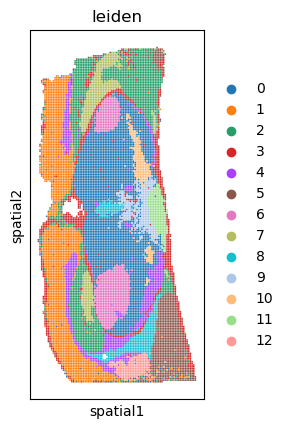

In [2]:
rna = ad.read_h5ad("E:/PythonFiles/msti/rna.h5ad")
rna.obsm['spatial'] = np.column_stack([rna.obs['x'].values, rna.obs['y'].values])
# 创建counts层
rna.layers["counts"] = rna.X.copy()

# 寻找高变异基因
sc.pp.highly_variable_genes(rna, flavor="cell_ranger", n_top_genes=2000)

# 归一化
sc.pp.normalize_total(rna, inplace=True)
#sc.pp.log1p(adata)

# 缩放数据
sc.pp.scale(rna)

# 执行PCA降维
sc.pp.pca(rna, n_comps=50)

# 寻找邻居
sc.pp.neighbors(rna)

# 使用UMAP进行降维
sc.tl.umap(rna)

# 使用Leiden算法进行聚类
sc.tl.leiden(
    rna,
    resolution=0.4,
    random_state=0,
    n_iterations=2,
    directed=False,
    key_added='leiden' 
)
sc.pl.spatial(rna, color="leiden", spot_size=1)

C:\Users\BYao\AppData\Local\Temp\ipykernel_41980\1579208906.py:33: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(meta, color="leiden", spot_size=1)


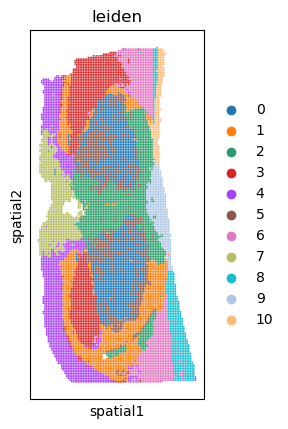

In [3]:
meta = ad.read_h5ad("E:/PythonFiles/msti/meta.h5ad")
meta.obsm['spatial'] = np.column_stack([meta.obs['x'].values, meta.obs['y'].values])
# 创建counts层
meta.layers["counts"] = meta.X.copy()

# 寻找高变异基因
sc.pp.highly_variable_genes(meta, flavor="cell_ranger", n_top_genes=2000)

# 归一化
sc.pp.normalize_total(meta, inplace=True)
# sc.pp.log1p(meta)

# 缩放数据
# sc.pp.scale(meta)

# 执行PCA降维
sc.pp.pca(meta, n_comps=50)

# 寻找邻居
sc.pp.neighbors(meta)

# 使用UMAP进行降维
sc.tl.umap(meta)

# 使用Leiden算法进行聚类
sc.tl.leiden(
    meta,
    resolution=0.4,
    random_state=0,
    n_iterations=2,
    directed=False,
)
sc.pl.spatial(meta, color="leiden", spot_size=1)

In [4]:
meta_bc = meta
rna_bc = rna

In [5]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix
import scanpy as sc
from itertools import chain
import itertools
import networkx as nx
import scglue
import seaborn as sns
from matplotlib import rcParams
import sys
import os
print(ad.__version__)
utils_path = "E:/PythonFiles/msti/MSTI-main/ST&SM Integrator"
if utils_path not in sys.path:
    sys.path.append(utils_path)
import MSTI_Guidancegraph as MG
import MSTI_preprocess as MP

0.9.2


In [6]:
def calculate_all_correlations_fast(meta, rna, threshold=0.5):
    """
    使用矩阵运算快速计算所有代谢物与所有基因之间的相关性
    
    参数:
    ----------
    meta : AnnData
        代谢物数据
    rna : AnnData
        RNA表达数据
    threshold : float
        相关系数绝对值阈值，默认为0.5
    
    返回:
    ----------
    filtered_df : DataFrame
        包含所有相关性大于阈值的代谢物-基因对
    """
    
    import pandas as pd
    import numpy as np
    from scipy import stats
    from tqdm import tqdm
    import warnings
    warnings.filterwarnings('ignore')
    
    # 转换为密集矩阵（如果内存允许）
    print("准备数据...")
    meta_data = meta.X
    rna_data = rna.X
    
    # 转换为密集数组
    if hasattr(meta_data, 'toarray'):
        meta_data = meta_data.toarray()
    if hasattr(rna_data, 'toarray'):
        rna_data = rna_data.toarray()
    
    # 确保是二维数组
    if meta_data.ndim == 1:
        meta_data = meta_data.reshape(-1, 1)
    if rna_data.ndim == 1:
        rna_data = rna_data.reshape(-1, 1)
    
    # 标准化数据（零均值，单位方差）- 加速相关性计算
    print("标准化数据...")
    meta_std = (meta_data - np.mean(meta_data, axis=0)) / (np.std(meta_data, axis=0) + 1e-10)
    rna_std = (rna_data - np.mean(rna_data, axis=0)) / (np.std(rna_data, axis=0) + 1e-10)
    
    # 计算相关性矩阵
    print("计算相关性矩阵...")
    corr_matrix = np.dot(meta_std.T, rna_std) / (meta_std.shape[0] - 1)
    
    # 获取代谢物和基因名称
    metabolites = meta.var_names.tolist()
    genes = rna.var_names.tolist()
    
    # 存储结果
    results = []
    
    print("提取显著相关性...")
    for i, metabolite in enumerate(tqdm(metabolites, desc="处理代谢物")):
        for j, gene in enumerate(genes):
            corr = corr_matrix[i, j]
            
            # 检查是否满足阈值
            if abs(corr) > threshold:
                # 计算p值
                # 使用近似方法计算p值，避免逐对计算
                n = meta_std.shape[0]
                if n > 2:
                    t_stat = corr * np.sqrt((n - 2) / (1 - corr**2 + 1e-10))
                    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
                else:
                    p_value = 1.0
                
                results.append({
                    'metabolite': metabolite,
                    'gene': gene,
                    'pearson_corr': corr,
                    'p_value': p_value,
                    'abs_corr': abs(corr)
                })
    
    # 创建 DataFrame
    if results:
        filtered_df = pd.DataFrame(results)
        
        # 按相关系数绝对值排序
        filtered_df = filtered_df.sort_values('abs_corr', ascending=False)
        
        print(f"\n相关性计算完成!")
        print(f"总组合数: {len(metabolites) * len(genes):,}")
        print(f"发现显著相关性组合: {len(filtered_df)} (|r| > {threshold})")
        
        # 统计信息
        pos_corr = len(filtered_df[filtered_df['pearson_corr'] > 0])
        neg_corr = len(filtered_df[filtered_df['pearson_corr'] < 0])
        
        print(f"  - 正相关: {pos_corr}")
        print(f"  - 负相关: {neg_corr}")
        
        # 显示前10个最强相关性
        if len(filtered_df) > 0:
            print(f"\n前10个最强相关性:")
            for i, (_, row) in enumerate(filtered_df.head(10).iterrows(), 1):
                sign = "+" if row['pearson_corr'] > 0 else "-"
                print(f"  {i:2d}. {row['metabolite']} - {row['gene']}: "
                      f"r = {row['pearson_corr']:.4f} (p = {row['p_value']:.2e})")
        
        return filtered_df
    else:
        print(f"没有找到相关系数绝对值大于 {threshold} 的组合")
        return pd.DataFrame()

In [7]:
def create_graph_from_data1(rna, meta, kegg_reaction):
    """
    创建生物网络图，并添加监视功能

    参数：
    rna: RNA数据
    meta: 代谢物数据
    kegg_reaction: KEGG反应数据

    返回：
    G: 构建的网络图
    """
    import networkx as nx

    G = nx.Graph()

    # 添加节点
    rna_nodes_to_add = rna.var.index.tolist()
    meta_nodes_to_add = meta.var.index.tolist()
    nodes_to_add = rna_nodes_to_add + meta_nodes_to_add
    G.add_nodes_from(nodes_to_add)

    print("=" * 60)
    print("图构建统计信息")
    print("=" * 60)
    print(f"总节点数: {G.number_of_nodes()}")
    print(f"  - RNA节点数: {len(rna_nodes_to_add)}")
    print(f"  - 代谢物节点数: {len(meta_nodes_to_add)}")
    print("-" * 60)

    # 初始化统计变量
    kegg_edge_count = 0
    precursor_found = []
    gene_found = []
    edges_added = []
    
    # 统计sign值
    sign_counts = {"positive": 0, "negative": 0, "zero": 0}
    
    # 权重统计
    weight_stats = {
        'min': float('inf'),
        'max': float('-inf'),
        'mean': 0,
        'sum': 0
    }

    # 添加 KEGG 反应边
    if kegg_reaction is not None:
        print(f"处理KEGG反应数据，共 {len(kegg_reaction)} 行")
        print("-" * 60)

        # 创建查找集合以提高效率
        rna_node_set = set(rna_nodes_to_add)
        meta_node_set = set(meta_nodes_to_add)
        all_node_set = rna_node_set.union(meta_node_set)

        for index, row in kegg_reaction.iterrows():
            precursor = str(row['metabolite']).strip()
            gene_name = str(row['gene']).strip()
            
            # 获取相关性值
            pearson_corr = row['pearson_corr']
            abs_corr = abs(pearson_corr)
            
            # 更新权重统计
            weight_stats['min'] = min(weight_stats['min'], abs_corr)
            weight_stats['max'] = max(weight_stats['max'], abs_corr)
            weight_stats['sum'] += abs_corr
            
            # 根据pearson_corr的正负确定sign值
            if pearson_corr > 0:
                sign = 1
                sign_counts["positive"] += 1
            elif pearson_corr < 0:
                sign = -1
                sign_counts["negative"] += 1
            else:
                sign = 1  # 默认值
                sign_counts["zero"] += 1

            # 检查节点是否存在
            precursor_exists = precursor in all_node_set
            gene_exists = gene_name in all_node_set

            if precursor_exists and gene_exists:
                # 添加边，使用abs_corr作为权重
                G.add_edge(precursor, gene_name, weight=abs_corr, sign=sign)
                kegg_edge_count += 1

                # 记录信息
                if precursor not in precursor_found:
                    precursor_found.append(precursor)
                if gene_name not in gene_found:
                    gene_found.append(gene_name)
                edges_added.append((precursor, gene_name, sign, abs_corr))
            else:
                # 记录未找到的节点（可选）
                if not precursor_exists and not gene_exists:
                    pass  # 两个都不存在
                elif not precursor_exists:
                    pass  # precursor不存在
                elif not gene_exists:
                    pass  # gene不存在

        # 计算平均权重
        if kegg_edge_count > 0:
            weight_stats['mean'] = weight_stats['sum'] / kegg_edge_count
        
        print(f"成功添加的KEGG边数量: {kegg_edge_count}")
        print(f"涉及的Precursor数量: {len(precursor_found)}")
        print(f"涉及的Gene数量: {len(gene_found)}")
        
        # 打印权重统计
        print(f"\n权重统计 (|r|):")
        print(f"  - 最小权重: {weight_stats['min']:.4f}")
        print(f"  - 最大权重: {weight_stats['max']:.4f}")
        print(f"  - 平均权重: {weight_stats['mean']:.4f}")
        
        # 打印sign值统计
        print(f"\nSign值统计:")
        print(f"  - 正相关边 (sign=1): {sign_counts['positive']}")
        print(f"  - 负相关边 (sign=-1): {sign_counts['negative']}")
        print(f"  - 零相关边 (sign=1): {sign_counts['zero']}")

        # 打印详细的边信息（前10条）
        if edges_added:
            print("\n前10条最强相关性的边:")
            # 按权重（abs_corr）排序
            sorted_edges = sorted(edges_added, key=lambda x: x[3], reverse=True)
            
            for i, (precursor, gene, sign, weight) in enumerate(sorted_edges[:10]):
                sign_symbol = "+" if sign == 1 else "-"
                print(f"  {i + 1}. {precursor} <-> {gene} "
                      f"(sign={sign_symbol}, weight={weight:.4f})")

            if len(sorted_edges) > 10:
                print(f"  ... 还有 {len(sorted_edges) - 10} 条边")

            # 显示统计信息
            print(f"\n  统计信息:")
            print(f"  - 原始边数: {len(edges_added)}")
            print(f"  - 去重后边数: {len(set((p, g) for p, g, _, _ in edges_added))}")
            print(f"  - 重复边数: {len(edges_added) - len(set((p, g) for p, g, _, _ in edges_added))}")

        print("-" * 60)

    # 添加自环
    print("添加自环边...")
    for node in G.nodes:
        # 自环的权重设为1（或者可以设为平均权重）
        G.add_edge(node, node, weight=1.0, sign=1)

    print(f"自环添加完成，总边数: {G.number_of_edges()}")
    
    # 最终统计
    print("\n最终图统计:")
    print(f"  - 总节点数: {G.number_of_nodes()}")
    print(f"  - 总边数: {G.number_of_edges()}")
    print(f"  - KEGG边数: {kegg_edge_count}")
    print(f"  - 自环边数: {G.number_of_nodes()}")
    
    # 计算图的整体权重统计
    if kegg_edge_count > 0:
        all_weights = [data['weight'] for u, v, data in G.edges(data=True) 
                      if u != v]  # 排除自环
        if all_weights:
            print(f"  - 边权重范围: {min(all_weights):.4f} - {max(all_weights):.4f}")
            print(f"  - 平均边权重: {sum(all_weights)/len(all_weights):.4f}")
    
    print("=" * 60)

    return G  # 返回图和详细信息

In [8]:
filtered_kegg =calculate_all_correlations_fast(meta_bc, rna_bc, threshold=0.1)
guidance = create_graph_from_data1(rna_bc, meta_bc, filtered_kegg)

准备数据...
标准化数据...
计算相关性矩阵...
提取显著相关性...


处理代谢物: 100%|████████████████████████████████████████████████████████████████████| 560/560 [00:06<00:00, 89.08it/s]



相关性计算完成!
总组合数: 5,600,000
发现显著相关性组合: 180489 (|r| > 0.1)
  - 正相关: 93950
  - 负相关: 86539

前10个最强相关性:
   1. Vaccenyl carnitine - Mbp: r = 0.7006 (p = 0.00e+00)
   2.  6'''-Deamino-6'''-oxoneomycin C; 6'''-Oxoneomycin C; 6'''-Deamino-6'''-dehydro-6'''-oxoneomycin C; - Mbp: r = 0.6542 (p = 0.00e+00)
   3. Vaccenyl carnitine - Fth1: r = 0.6509 (p = 0.00e+00)
   4. [D-Met2, Pro5]-enkephalinamide - Mbp: r = 0.6496 (p = 0.00e+00)
   5. Vaccenyl carnitine - Mobp: r = 0.6480 (p = 0.00e+00)
   6. Simvastatin - Mbp: r = 0.6449 (p = 0.00e+00)
   7. N-Stearoyl Aspartic acid - Mbp: r = 0.6409 (p = 0.00e+00)
   8. Vaccenyl carnitine - Plp1: r = 0.6407 (p = 0.00e+00)
   9. 1-Oleoyl-rac-glycerol - Mbp: r = 0.6387 (p = 0.00e+00)
  10.  Cholestane; - Mbp: r = 0.6334 (p = 0.00e+00)
图构建统计信息
总节点数: 10560
  - RNA节点数: 10000
  - 代谢物节点数: 560
------------------------------------------------------------
处理KEGG反应数据，共 180489 行
------------------------------------------------------------
成功添加的KEGG边数量: 103764
涉及的Precurso

In [9]:
scglue.graph.check_graph(guidance, [rna, meta])

[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] check_graph: All checks passed!


In [10]:
scglue.models.configure_dataset(
    rna, "NB", use_layer="counts",use_highly_variable=True,
    use_rep="X_pca"
)
scglue.models.configure_dataset(
    meta, "NB", use_layer="counts",use_highly_variable=True,
     use_rep="X_pca"
)
guidance_hvf = guidance.subgraph(chain(
    rna.var.query("highly_variable").index,
    meta.var.query("highly_variable").index
)).copy()

In [11]:
glue = scglue.models.fit_SCGLUE(
    {"rna": rna, "meta": meta}, guidance_hvf,
    fit_kws={"directory": "glue"}
)

[INFO] fit_SCGLUE: Pretraining SCGLUE model...
[INFO] autodevice: Using GPU 0 as computation device.
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 5499
[INFO] SCGLUEModel: Setting `max_epochs` = 118
[INFO] SCGLUEModel: Setting `patience` = 10
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 5
[INFO] SCGLUETrainer: Using training directory: "glue\pretrain"
[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 1.04, 'g_kl': 0.024, 'g_elbo': 1.064, 'x_rna_nll': 0.395, 'x_rna_kl': 0.014, 'x_rna_elbo': 0.409, 'x_meta_nll': 11.46, 'x_meta_kl': 0.087, 'x_meta_elbo': 11.548, 'dsc_loss': 0.599, 'vae_loss': 11.999, 'gen_loss': 11.969}, val={'g_nll': 1.022, 'g_kl': 0.024, 'g_elbo': 1.046, 'x_rna_nll': 0.399, 'x_rna_kl': 0.012, 'x_rna_elbo': 0.411, 'x_meta_nll': 11.236, 'x_meta_kl': 0.088, 'x_meta_elbo': 11.324, 

2025-12-24 22:13:03,396 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "88"...
[INFO] EarlyStopping: Restoring checkpoint "88"...
[INFO] fit_SCGLUE: Estimating balancing weight...
[INFO] estimate_balancing_weight: Clustering cells...
[INFO] estimate_balancing_weight: Matching clusters...
[INFO] estimate_balancing_weight: Matching array shape = (24, 27)...
[INFO] estimate_balancing_weight: Estimating balancing weight...
[INFO] fit_SCGLUE: Fine-tuning SCGLUE model...
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 5499
[INFO] SCGLUEModel: Setting `align_burnin` = 20
[INFO] SCGLUEModel: Setting `max_epochs` = 118
[INFO] SCGLUEModel: Setting `patience` = 10
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 5
[INFO] SCGLUETrainer: Using training directory: "glue\fine-tune"
[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.495, 'g_

2025-12-24 22:19:16,428 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "63"...
[INFO] EarlyStopping: Restoring checkpoint "63"...


In [12]:
rna.obsm["X_glue"] = glue.encode_data("rna", rna)
meta.obsm["X_glue"] = glue.encode_data("meta", meta)
rna.obs['domain'] = 'rna'
meta.obs['domain'] = 'meta'
combined = ad.concat([rna, meta])

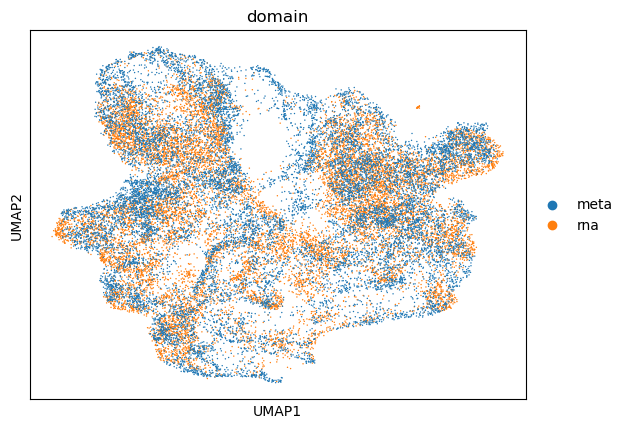

In [13]:
sc.pp.neighbors(combined, use_rep="X_glue", metric="cosine")
sc.tl.umap(combined)
sc.pl.umap(combined, color='domain', wspace=0.65)

In [14]:
rna_index = rna_bc
rna = combined[combined.obs['domain'] == 'rna']
meta = combined[combined.obs['domain'] == 'meta']
df_rna = pd.DataFrame(rna.obsm['X_glue'])
df_meta = pd.DataFrame(meta.obsm['X_glue'])
df_rna_adata = ad.AnnData(X=df_rna)
df_meta_adata = ad.AnnData(X=df_meta)
df_rna_adata.obs = pd.DataFrame(index=rna.obs.index)
df_meta_adata.obs = pd.DataFrame(index=meta.obs.index)
df_meta_adata.obs['x'] = df_meta_adata.obs.index.str.split('x').str[0]
df_meta_adata.obs['y'] = df_meta_adata.obs.index.str.split('x').str[1]
df_meta_adata.obs['array_row'] = df_meta_adata.obs['x']
df_meta_adata.obs['array_col'] = df_meta_adata.obs['y']
# df_meta_adata.obs['x_spa'] = df_meta_adata.obs['x'].astype(float) * 117.6471
# df_meta_adata.obs['y_spa'] = df_meta_adata.obs['y'].astype(float) * 117.6471
df_rna_adata.obs['domain'] = 'rna'
df_meta_adata.obs['domain'] = 'meta'
combined = ad.concat([df_rna_adata, df_meta_adata])

In [15]:
combined.var_names_make_unique()
combined.layers["counts"] = combined.X.copy()
sc.pp.neighbors(combined)
sc.tl.umap(combined)

In [16]:
sc.tl.leiden(
    combined,
    resolution=0.4,
    random_state=0,
    directed=False,
)

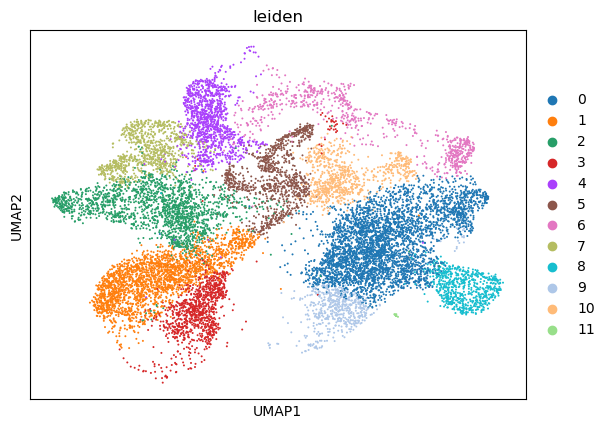

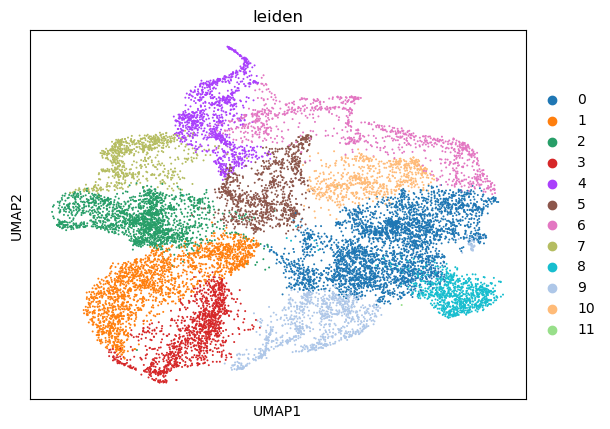

In [17]:
domain_rna = combined[combined.obs['domain'] == 'rna']
sc.pl.umap(domain_rna, color='leiden')
domain_meta = combined[combined.obs['domain'] == 'meta']
sc.pl.umap(domain_meta, color='leiden')

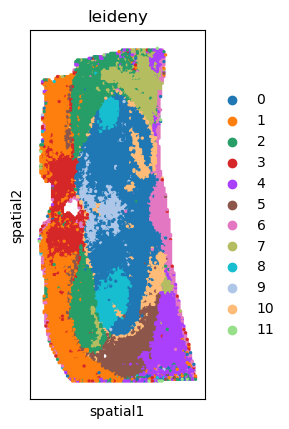

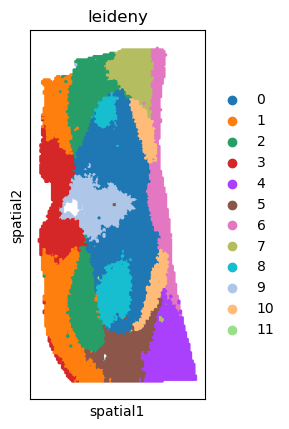

In [18]:
meta_spa = meta_bc
rna_spa = rna_bc
rna_spa.obs['leideny'] = domain_rna.obs['leiden']
sc.pl.spatial(rna_spa, color="leideny",spot_size=2)
meta_spa.obs['leideny'] = domain_meta.obs['leiden']
sc.pl.spatial(meta_spa, color="leideny", spot_size=2)

In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score, silhouette_samples, homogeneity_score, completeness_score, v_measure_score
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, Optional, List

In [20]:
def evaluate_clustering_agreement(adata_st, adata_sm, leiden_st, leiden_sm):
    """
    计算两个adata中聚类结果的一致性指标
    
    参数:
    adata_st: 第一个AnnData对象
    adata_sm: 第二个AnnData对象
    leiden_st: 第一个adata中的聚类标签列名
    leiden_sm: 第二个adata中的聚类标签列名
    
    返回:
    ari: Adjusted Rand Index
    nmi: Normalized Mutual Information
    asw: Isolated label ASW (以ST为真实值，SM为预测值)
    """
    
    # 提取聚类标签
    labels_st = adata_st.obs[leiden_st].astype(str).values
    labels_sm = adata_sm.obs[leiden_sm].astype(str).values
    
    # 确保顺序一致
    if len(labels_st) != len(labels_sm):
        print("警告: 两个adata的样本数不一致!")
        min_len = min(len(labels_st), len(labels_sm))
        labels_st = labels_st[:min_len]
        labels_sm = labels_sm[:min_len]
    
    # 计算ARI和NMI
    ari = adjusted_rand_score(labels_st, labels_sm)
    nmi = normalized_mutual_info_score(labels_st, labels_sm)
    
    # 计算Isolated label ASW
    # 将聚类标签转换为数值型
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    labels_st_num = le.fit_transform(labels_st)
    labels_sm_num = le.fit_transform(labels_sm)
    
    # 使用一个简单的距离矩阵（基于聚类标签是否相同）
    n_samples = len(labels_st_num)
    distance_matrix = np.zeros((n_samples, n_samples))
    
    for i in range(n_samples):
        for j in range(n_samples):
            # 如果预测的聚类标签相同，距离为0，否则为1
            distance_matrix[i, j] = 0 if labels_sm_num[i] == labels_sm_num[j] else 1
    
    # 计算silhouette scores
    sil_scores = silhouette_samples(distance_matrix, labels_st_num, metric='precomputed')
    
    # 排除只有一个样本的簇
    unique_labels, counts = np.unique(labels_st_num, return_counts=True)
    valid_labels = unique_labels[counts > 1]
    
    if len(valid_labels) > 0:
        mask = np.isin(labels_st_num, valid_labels)
        asw = np.mean(sil_scores[mask])
    else:
        asw = 0
    
    return ari, nmi, asw


In [21]:
ari, nmi, asw = evaluate_clustering_agreement(rna_spa, meta_spa, "leideny", "leideny")
print(f"ARI: {ari:.3f}, NMI: {nmi:.3f}, ASW: {asw:.3f}")

ARI: 0.555, NMI: 0.590, ASW: 0.297


In [22]:
ari, nmi, asw = evaluate_clustering_agreement(rna_spa, meta_spa, "leiden", "leiden")
print(f"ARI: {ari:.3f}, NMI: {nmi:.3f}, ASW: {asw:.3f}")

ARI: 0.283, NMI: 0.439, ASW: -0.113


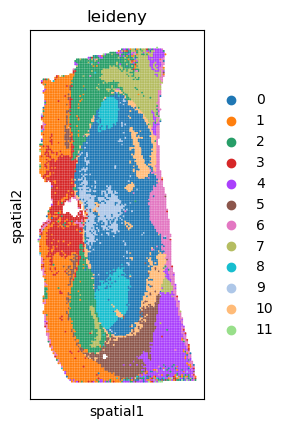

In [23]:
sc.pl.spatial(rna_spa, color="leideny",spot_size=1.2,save='omix_msti_rna.svg')

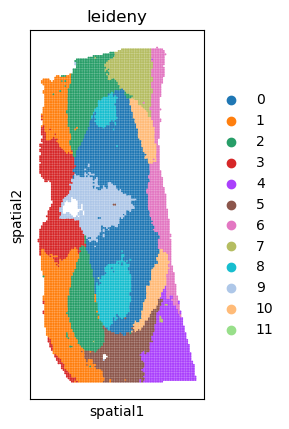

In [24]:
sc.pl.spatial(meta_spa, color="leideny", spot_size=1.2,save='omix_msti_meta.svg')

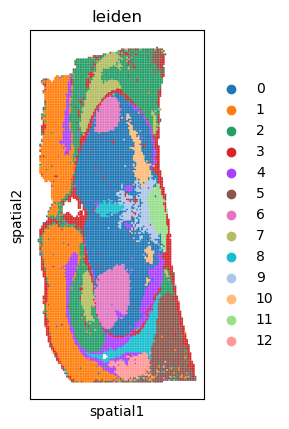

In [25]:
sc.pl.spatial(rna_spa, color="leiden",spot_size=1.2,save='omix_rna.svg')

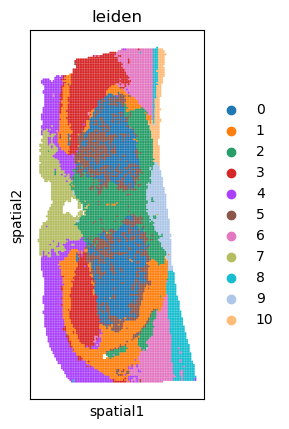

In [26]:
sc.pl.spatial(meta_spa, color="leiden", spot_size=1.2,save='omix_meta.svg')